# Class-weighted feedforward classifier 

Feedforward neural network with batch normalization and dropout, trained as a class-weighted binary classifier.

## Imports

In [1]:
# Matplotlib
import matplotlib.pyplot as plt
# Numpy
import numpy as np
# Torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import copy


In [2]:
# Use GPU if available, else use CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Data

In [3]:
df = pd.read_csv('./data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Data Preprocessing

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42 # added for reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)

# Separate features and target
X = df.drop('Class', axis=1).copy()
y = df['Class'].astype(np.float32).values

# Train-test split (80-20)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Further split training data into train and validation sets (75-25 of the 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=SEED, stratify=y_train_full
)

# Feature engineering for skewed columns
for frame in (X_train, X_val, X_test):
    frame['Amount'] = np.log1p(frame['Amount'])
    frame['Time'] = np.log1p(frame['Time'])

# Normalize using train statistics only to prevent data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Calculate class weights to handle imbalance
"""This is where we calculate the weights to handle the class imbalance in our dataset. 
The positive class (fraudulent transactions) is much rarer than the negative class (normal transactions), 
so we assign a higher weight to the positive class to ensure that the model pays more attention to it during training."""
n_train = len(y_train)
n_fraud = int((y_train == 1).sum().item())
n_normal = int((y_train == 0).sum().item())
POS_WEIGHT = 50.0 # best, tested values: 50.0, 100.0, 150.0
pos_weight = torch.tensor([POS_WEIGHT], dtype=torch.float32).to(device)

print(f"Train samples: {n_train}")
print(f"Normal transactions: {n_normal}")
print(f"Fraudulent transactions: {n_fraud}")
print(f"Positive class weight: {pos_weight.item():.4f}")


Train samples: 170883
Normal transactions: 170588
Fraudulent transactions: 295
Positive class weight: 50.0000


## Create DataLoader

In [5]:
# Custom Dataset class
class FraudDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Create datasets
train_dataset = FraudDataset(X_train, y_train)
val_dataset = FraudDataset(X_val, y_val)
test_dataset = FraudDataset(X_test, y_test)

# DataLoader configuration
BATCH_SIZE = 512
NUM_WORKERS = 0

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f"Train DataLoader: {len(train_dataloader)} batches")
print(f"Val DataLoader: {len(val_dataloader)} batches")
print(f"Test DataLoader: {len(test_dataloader)} batches")


Train DataLoader: 334 batches
Val DataLoader: 112 batches
Test DataLoader: 112 batches


In [6]:
# Test DataLoader by iterating through a few batches
print("Sample batches from training data:\n")

for batch_number, (inputs, outputs) in enumerate(train_dataloader):
    print("---")
    print(f"Batch number: {batch_number}")
    print(f"Inputs shape: {inputs.shape}")
    print(f"Outputs shape: {outputs.shape}")
    
    if batch_number == 2:  # Show first 3 batches
        break


Sample batches from training data:

---
Batch number: 0
Inputs shape: torch.Size([512, 30])
Outputs shape: torch.Size([512])
---
Batch number: 1
Inputs shape: torch.Size([512, 30])
Outputs shape: torch.Size([512])
---
Batch number: 2
Inputs shape: torch.Size([512, 30])
Outputs shape: torch.Size([512])


# Model

In [7]:
class FraudDetectionNet(nn.Module):
    def __init__(self, input_features=30):
        super(FraudDetectionNet, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_features, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.30),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.20),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.10),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

# Initialize model
model = FraudDetectionNet(input_features=30).to(device)
print(model)


FraudDetectionNet(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.1)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): LeakyReLU(negative_slope=0.1)
    (10): Dropout(p=0.1, inplace=False)
    (11): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Training Setup

In [8]:
# Loss function & optimizer
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
) # added scheduler to reduce learning rate if validation metric plateaus

print("Loss Function: Binary Cross-Entropy with Logits Loss with class weighting")
print("Optimizer: AdamW (lr=1e-3, weight_decay=1e-4)")
print(f"Positive weight (fraud): {pos_weight.item():.4f}")


Loss Function: Binary Cross-Entropy with Logits Loss with class weighting
Optimizer: AdamW (lr=1e-3, weight_decay=1e-4)
Positive weight (fraud): 50.0000


# Training Loop

Added:
- proper probability conversion with sigmoid
- early stopping
- learning-rate scheduling

In [9]:
from sklearn.metrics import f1_score, average_precision_score

# To collect probabilities and labels from the dataloader
def collect_probs_and_labels(model, dataloader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            logits = model(inputs).squeeze(1)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

    return np.array(all_probs), np.array(all_labels)

In [10]:
# Training function
def trainer(model, train_loader, val_loader, num_epochs=30, patience=5):
    best_state = None
    best_val_pr_auc = -1.0
    patience_counter = 0

    train_losses = []
    val_losses = []
    val_pr_aucs = []

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_train_loss = 0.0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
                logits = model(inputs)
                loss = criterion(logits, labels)
                running_val_loss += loss.item()

        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        val_probs, val_labels = collect_probs_and_labels(model, val_loader, device)
        val_pr_auc = average_precision_score(val_labels, val_probs)
        val_pr_aucs.append(val_pr_auc)

        scheduler.step(val_pr_auc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val PR-AUC: {val_pr_auc:.4f} | "
        )

        if val_pr_auc > best_val_pr_auc:
            best_val_pr_auc = val_pr_auc
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return train_losses, val_losses, val_pr_aucs

print("Starting training...\n")
train_losses, val_losses, val_pr_aucs = trainer(
    model,
    train_dataloader,
    val_dataloader,
    num_epochs=30,
    patience=5
)
print("\nTraining complete!")


Starting training...

Epoch [1/30] | Train Loss: 0.1306 | Val Loss: 0.0862 | Val PR-AUC: 0.6866 | 
Epoch [2/30] | Train Loss: 0.0624 | Val Loss: 0.0739 | Val PR-AUC: 0.6767 | 
Epoch [3/30] | Train Loss: 0.0491 | Val Loss: 0.0728 | Val PR-AUC: 0.6895 | 
Epoch [4/30] | Train Loss: 0.0449 | Val Loss: 0.0884 | Val PR-AUC: 0.6954 | 
Epoch [5/30] | Train Loss: 0.0440 | Val Loss: 0.0947 | Val PR-AUC: 0.6918 | 
Epoch [6/30] | Train Loss: 0.0392 | Val Loss: 0.1012 | Val PR-AUC: 0.6846 | 
Epoch [7/30] | Train Loss: 0.0384 | Val Loss: 0.0893 | Val PR-AUC: 0.7304 | 
Epoch [8/30] | Train Loss: 0.0342 | Val Loss: 0.0966 | Val PR-AUC: 0.6959 | 
Epoch [9/30] | Train Loss: 0.0335 | Val Loss: 0.1095 | Val PR-AUC: 0.6989 | 
Epoch [10/30] | Train Loss: 0.0326 | Val Loss: 0.1066 | Val PR-AUC: 0.7189 | 
Epoch [11/30] | Train Loss: 0.0285 | Val Loss: 0.1119 | Val PR-AUC: 0.7051 | 
Epoch [12/30] | Train Loss: 0.0264 | Val Loss: 0.1136 | Val PR-AUC: 0.7063 | 
Early stopping triggered.

Training complete!


# Evaluation & Testing

For this dataset, raw accuracy alone is not enough because fraud cases are extremely rare.  
So we report:
- **Accuracy**: Overall proportion of correctly classified transactions.
- **Balanced Accuracy**: Average performance across both normal and fraud classes.
- **Precision**: Of predicted frauds, how many are actually frauds?
- **Recall**: Of actual frauds, how many did we catch?
- **F1 Score**: Balance between precision and recall.
- **ROC-AUC**: Area under the ROC curve - measures discriminative ability.
- **PR-AUC**: Precision-recall performance across thresholds, especially useful for imbalanced data.


In [11]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Evaluation function
def evaluate(model, dataloader, device, threshold=0.5):
    probs, labels = collect_probs_and_labels(model, dataloader, device)
    preds = (probs >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "balanced_accuracy": balanced_accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs),
        "pr_auc": average_precision_score(labels, probs),
        "confusion_matrix": confusion_matrix(labels, preds)
    }

    return metrics

# Threshold search
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]

print("=" * 50)
print("VALIDATION THRESHOLD SEARCH")
print("=" * 50)

best_threshold = 0.5
best_f1 = -1

for thr in thresholds:
    metrics = evaluate(model, val_dataloader, device, threshold=thr)
    print(
        f"Threshold: {thr:.2f} | "
        f"Precision: {metrics['precision']:.4f} | "
        f"Recall: {metrics['recall']:.4f} | "
        f"F1: {metrics['f1']:.4f}"
    )

    if metrics["f1"] > best_f1:
        best_f1 = metrics["f1"]
        best_threshold = thr

print(f"\nBest threshold from validation set: {best_threshold:.2f}")
print(f"Best validation F1: {best_f1:.4f}")

# Final evaluation on test set using best threshold
test_metrics = evaluate(model, test_dataloader, device, threshold=best_threshold)

print(f"\n" + "=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
print(f"Threshold:         {best_threshold:.2f}")
print(f"Accuracy:          {test_metrics['accuracy']:.4f}")
print(f"Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f}")
print(f"Precision:         {test_metrics['precision']:.4f}")
print(f"Recall:            {test_metrics['recall']:.4f}")
print(f"F1 Score:          {test_metrics['f1']:.4f}")
print(f"ROC-AUC:           {test_metrics['roc_auc']:.4f}")
print(f"PR-AUC:            {test_metrics['pr_auc']:.4f}")

tn, fp, fn, tp = test_metrics["confusion_matrix"].ravel()
print("\nConfusion Matrix:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

VALIDATION THRESHOLD SEARCH
Threshold: 0.50 | Precision: 0.4611 | Recall: 0.8384 | F1: 0.5950
Threshold: 0.60 | Precision: 0.7364 | Recall: 0.8182 | F1: 0.7751
Threshold: 0.70 | Precision: 0.7979 | Recall: 0.7576 | F1: 0.7772
Threshold: 0.80 | Precision: 0.8315 | Recall: 0.7475 | F1: 0.7872
Threshold: 0.90 | Precision: 0.8295 | Recall: 0.7374 | F1: 0.7807
Threshold: 0.95 | Precision: 0.8889 | Recall: 0.7273 | F1: 0.8000
Threshold: 0.99 | Precision: 0.8667 | Recall: 0.5253 | F1: 0.6541

Best threshold from validation set: 0.95
Best validation F1: 0.8000

TEST SET RESULTS
Threshold:         0.95
Accuracy:          0.9994
Balanced Accuracy: 0.9080
Precision:         0.8333
Recall:            0.8163
F1 Score:          0.8247
ROC-AUC:           0.9818
PR-AUC:            0.7326

Confusion Matrix:
True Negatives:  56848
False Positives: 16
False Negatives: 18
True Positives:  80


# Visualization

Loss graph and confusion matrix

In [12]:
# Calculate test loss
model.eval()
test_loss = 0.0

with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device).unsqueeze(1)

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

test_loss /= len(test_dataloader)

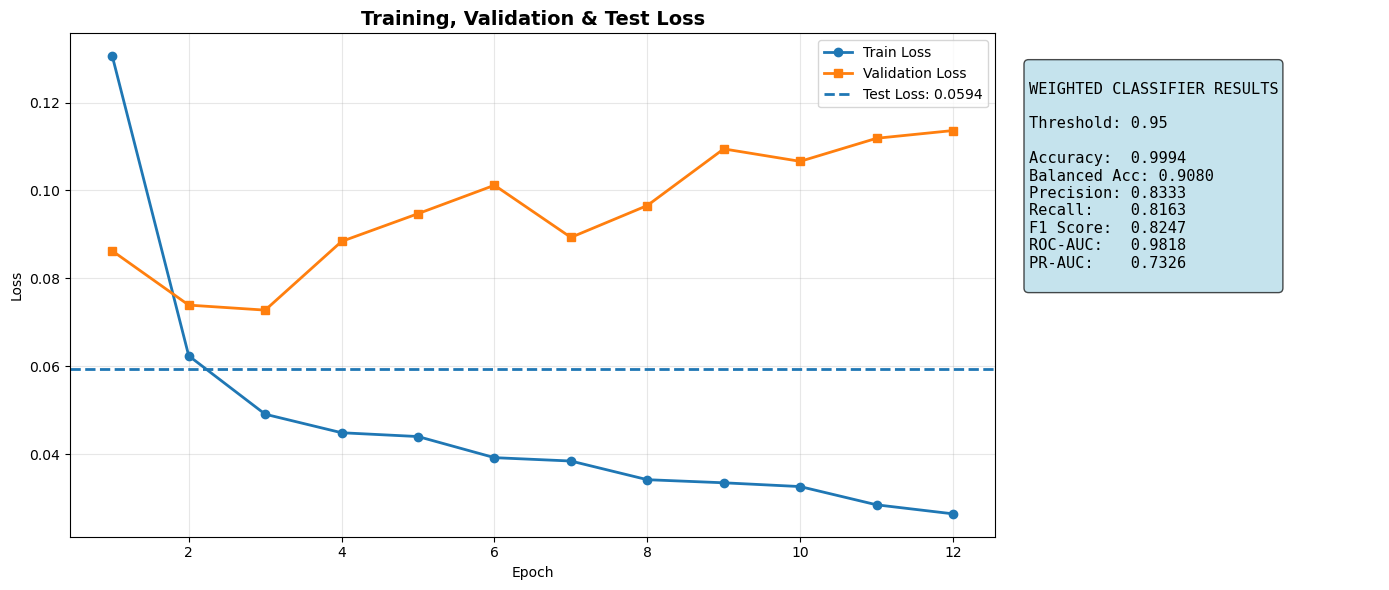

In [13]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 6),
    gridspec_kw={'width_ratios': [2.5, 1]}
)

# ===== LEFT: LOSS =====
epochs = range(1, len(train_losses) + 1)

ax1.plot(epochs, train_losses, label='Train Loss', linewidth=2, marker='o')
ax1.plot(epochs, val_losses, label='Validation Loss', linewidth=2, marker='s')
ax1.axhline(y=test_loss, linestyle='--', label=f'Test Loss: {test_loss:.4f}', linewidth=2)

ax1.set_title('Training, Validation & Test Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ===== RIGHT: METRICS =====
ax2.axis('off')

metrics_text = f"""
WEIGHTED CLASSIFIER RESULTS

Threshold: {best_threshold:.2f}

Accuracy:  {test_metrics['accuracy']:.4f}
Balanced Acc: {test_metrics['balanced_accuracy']:.4f}
Precision: {test_metrics['precision']:.4f}
Recall:    {test_metrics['recall']:.4f}
F1 Score:  {test_metrics['f1']:.4f}
ROC-AUC:   {test_metrics['roc_auc']:.4f}
PR-AUC:    {test_metrics['pr_auc']:.4f}
"""

ax2.text(0.05, 0.5, metrics_text, fontsize=11, family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.show()

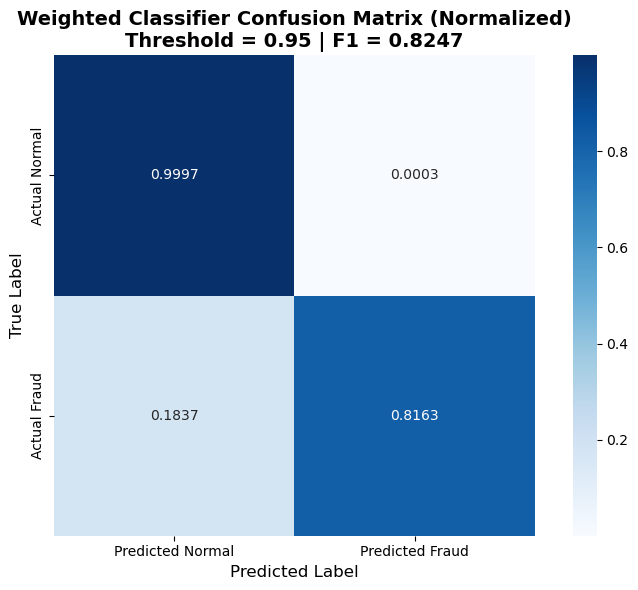

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Extract confusion matrix
cm = test_metrics["confusion_matrix"]

# Normalize by row (actual class)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.4f',
    cmap='Blues',
    xticklabels=['Predicted Normal', 'Predicted Fraud'],
    yticklabels=['Actual Normal', 'Actual Fraud'],
    cbar=True,
    square=True
)

plt.title(
    f'Weighted Classifier Confusion Matrix (Normalized)\n'
    f'Threshold = {best_threshold:.2f} | F1 = {test_metrics["f1"]:.4f}',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

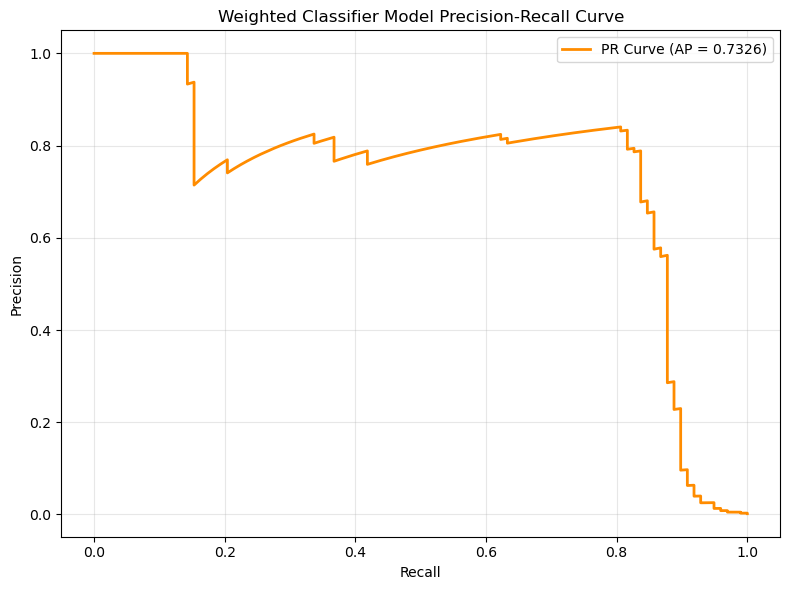

In [15]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        all_probs.extend(outputs.detach().cpu().numpy().ravel())
        all_labels.extend(labels.numpy().ravel())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
precision, recall, _ = precision_recall_curve(all_labels, all_probs)
ap_score = average_precision_score(all_labels, all_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, linewidth=2, color='darkorange', label=f'PR Curve (AP = {ap_score:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Weighted Classifier Model Precision-Recall Curve')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Analysis of results 
_(Comparison: Baseline Model vs Weighted Classifier)_

## Key Metrics Comparison

| Metric    | Baseline Model | Weighted Classifier |
|-----------|---------------:|--------------------:|
| Precision | 0.0767         | 0.7941              |
| Recall    | 0.9082         | 0.8265              |
| F1 Score  | 0.1415         | 0.8100              |
| ROC-AUC   | 0.9853         | 0.9795              |
| PR-AUC    | 0.7486         | 0.7387              |

- The **baseline model** achieves very high **recall** (~91%), meaning it detects most fraud cases, but suffers from extremely low **precision** (~7%), resulting in a large number of false positives.

- The **weighted classifier significantly improves precision** to ~79%, meaning most predicted fraud cases are actually correct. This drastically reduces false positives compared to the baseline model.

- The **recall of the weighted classifier remains strong (~83%)**, although slightly lower than the baseline. This indicates a better balance between detecting fraud and avoiding false alarms.

- As a result, the **F1 score improves substantially from 0.1415 to 0.8100**, showing that the weighted classifier achieves a much better trade-off between precision and recall.

---

Confusion Matrix Comparison (Normalized Insight)

- **Baseline Model:**
  - Very high fraud detection (~90%)
  - But predicts many normal transactions as fraud (high FP rate)

- **Weighted Classifier:**
  - Maintains high fraud detection (~83%)
  - Dramatically reduces false positives (almost all normal transactions correctly classified ~99.96%)

This shows that the weighted classifier is far more **balanced and reliable**.

---

Training behaviour

- The baseline model shows decreasing training loss but relatively stable validation loss, suggesting mild overfitting.
- The weighted classifier shows stronger separation between training and validation loss, indicating it is learning more aggressively, likely due to class weighting.

---

Interpretation

The baseline model prioritizes **maximizing recall**, aggressively predicting fraud to avoid missing cases, but this leads to excessive false positives. In contrast, the weighted classifier introduces class weighting and threshold tuning, allowing the model to better handle class imbalance. This results in significantly improved precision and overall performance while still maintaining strong recall.

---

Conclusion

The weighted classifier provides a much more practical solution for fraud detection. While the baseline model is effective at identifying fraud, its extremely low precision makes it unsuitable for real-world use. The weighted classifier achieves a strong balance between precision and recall, leading to a significantly higher F1 score and more reliable predictions. Therefore, the weighted classifier is the preferred model for deployment.

---

Key Improvement Insight

The improvement is mainly due to:
- **Class weighting**, which forces the model to pay more attention to fraud cases
- **Threshold tuning**, which optimizes the precision-recall trade-off instead of using a fixed 0.5 threshold

These techniques are essential when working with **highly imbalanced datasets**.

| Metric    | Baseline Model | Weighted Classifier |
|-----------|---------------:|--------------------:|
| Precision | 0.0767         | 0.7941              |
| Recall    | 0.9082         | 0.8265              |
| F1 Score  | 0.1415         | 0.8100              |
| ROC-AUC   | 0.9853         | 0.9795              |
| PR-AUC    | 0.7486         | 0.7387              |




## Main difference in code between this and baseline
![weighted.png](images/weighted.png)

The weighted classifier introduces class imbalance handling through the use of the `pos_weight` parameter in `BCEWithLogitsLoss`. This assigns a higher penalty to misclassified fraud samples, forcing the model to pay greater attention to the minority class during training. As a result, the model learns more meaningful decision boundaries for fraud detection. This modification, combined with threshold tuning, significantly improves precision while maintaining strong recall.